# Modality confusion by model

In [ ]:
from vggsounder.benchmark import benchmark
from vggsounder.labels import VGGSounder

vggsounder = VGGSounder()
mu_table = benchmark(
    models_path="../../supplimentary/models-results",
    display_names = {
        "ola": "OLA",
        "video-llama-2-av": "VideoLLaMA 2",
        "gemini-1.5-flash": "Gemini 1.5 Flash",
        "gemini-2.0-flash": "Gemini 2.0 Flash",
        
        "cav-mae": "CAV-MAE",
        "deepavfusion": "DeepAVFusion",
        "equiav": "Equi-AV",
        "avsiam": "AV-Siam",
    },
    metrics=[
        ("mu",["a", "v", "av"])
    ],
    vggsounder=vggsounder
)

  0%|          | 0/8 [00:00<?, ?it/s]

/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(


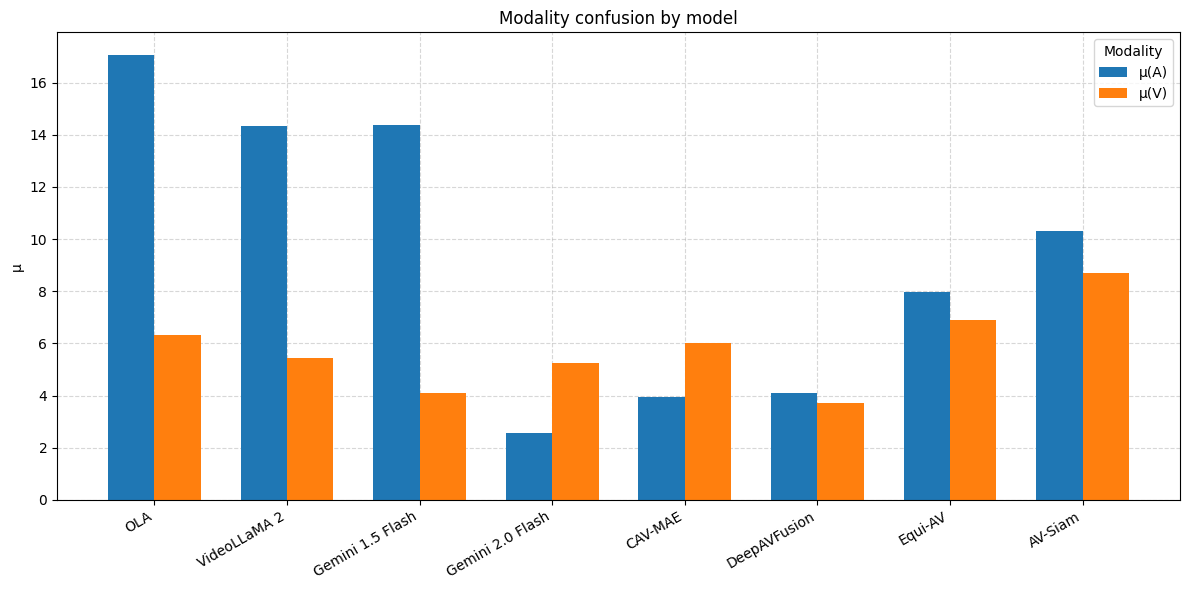

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

flattened_df = pd.DataFrame(mu_table.values, index=mu_table.index, columns=["a", "v"])

x = range(len(flattened_df.index))
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

# Draw grid first, then bars so grid is behind
ax.grid(True, which='both', linestyle='--', alpha=0.5, zorder=0)

ax.bar([i - width/2 for i in x], flattened_df["a"], width, label="μ(A)", zorder=2)
ax.bar([i + width/2 for i in x], flattened_df["v"], width, label="μ(V)", zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(flattened_df.index, rotation=30, ha='right')
ax.set_title('Modality confusion by model')
# ax.set_xlabel('Model')
ax.set_ylabel('μ')
ax.legend(title='Modality')

plt.tight_layout()
plt.savefig("modality_confusion_by_model.png", dpi=300, bbox_inches='tight')


plt.show()

## Background music

In [ ]:
from vggsounder.benchmark import benchmark
from vggsounder.labels import VGGSounder

models_path = "../../supplimentary/models-results"
csv_path = "../../supplimentary/data/vggsounder+background-music.csv"
display_names = {
    "ola": "OLA",
    "video-llama-2-av": "VideoLLaMA 2",
    "gemini-1.5-flash": "Gemini 1.5 Flash",
    "gemini-2.0-flash": "Gemini 2.0 Flash",
    "gemini-1.5-pro": "Gemini 1.5 Pro",
    "unified-io-2": "Unified-IO 2",
    "pandagpt": "PandaGPT",
}

# no background music
vggsounder = VGGSounder(csv_path=csv_path)
vggsounder.set_meta_filters(background_music=False)
no_background_music_ids = [video.video_id for video in vggsounder]

no_background_music_table = benchmark(
    models_path=models_path,
    display_names=display_names,
    metrics=[
        ("f1", ["av"]),
    ],
    subset_ids=no_background_music_ids,
    dataset_path=csv_path
)
no_background_music_table

# with background music
vggsounder = VGGSounder(background_music=True) 
background_music_ids = [video.video_id for video in vggsounder]

background_music_table = benchmark(
    models_path=models_path,
    display_names=display_names,
    metrics=[
        ("f1", ["av"]),
    ],
    subset_ids=background_music_ids,
    dataset_path=csv_path
)
background_music_table

diff_background_music_table = no_background_music_table - background_music_table
diff_background_music_table

  0%|          | 0/7 [00:00<?, ?it/s]

/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['wind rustiling leaves'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['wind rustiling leaves'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(


  0%|          | 0/7 [00:00<?, ?it/s]

metric,f1
modality,av
OLA,9.372342
VideoLLaMA 2,9.527947
Gemini 1.5 Flash,6.793869
Gemini 2.0 Flash,4.445412
Gemini 1.5 Pro,11.293324
Unified-IO 2,6.518547
PandaGPT,5.117389


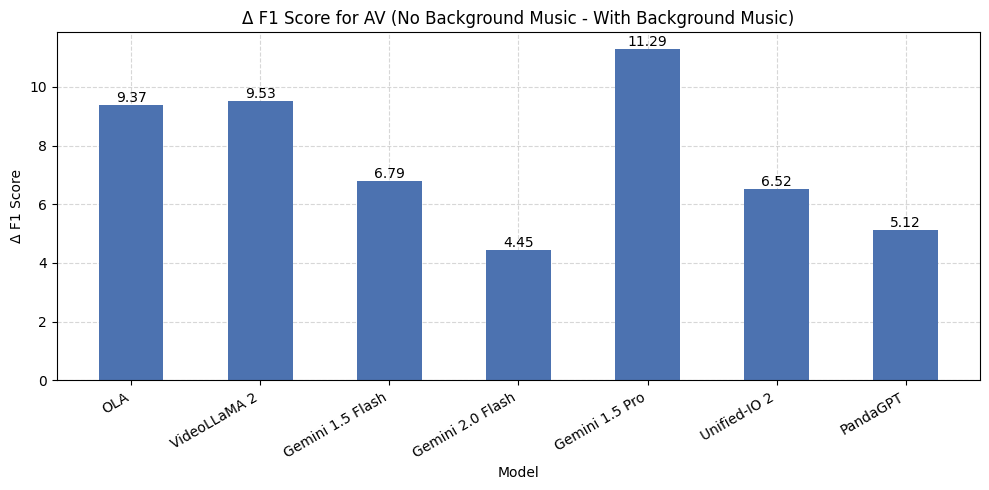

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure the DataFrame is properly formatted
flattened_df = pd.DataFrame(diff_background_music_table.values, index=diff_background_music_table.index, columns=["av"])

x = np.arange(len(flattened_df.index))
width = 0.5  # Make bars wider for clarity

const = 1.2
fig, ax = plt.subplots(figsize=(12 / const, 6 / const))

# Draw grid first, then bars so grid is behind
ax.grid(True, which='both', linestyle='--', alpha=0.5, zorder=0)
bars = ax.bar(x, flattened_df["av"], width, color="#4C72B0", label="Δ F1 (no BGM - BGM)", zorder=2)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 0),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)


ax.set_xticks(x)
ax.set_xticklabels(flattened_df.index, rotation=30, ha='right')
ax.set_title('Δ F1 Score for AV (No Background Music - With Background Music)')
ax.set_xlabel('Model')
ax.set_ylabel('Δ F1 Score')
# ax.legend(title='Difference')

plt.tight_layout()
plt.savefig("diff_background_music.png", dpi=300, bbox_inches='tight')
plt.show()

## Static images

In [ ]:
from vggsounder.benchmark import benchmark
from vggsounder.labels import VGGSounder

models_path = "../../supplimentary/models-results"
csv_path = "../../supplimentary/data/vggsounder+background-music.csv"
display_names = {
    "ola": "OLA",
    "video-llama-2-av": "VideoLLaMA 2",
    "gemini-1.5-flash": "Gemini 1.5 Flash",
    "gemini-2.0-flash": "Gemini 2.0 Flash",
    "gemini-1.5-pro": "Gemini 1.5 Pro",
    "unified-io-2": "Unified-IO 2",
    "pandagpt": "PandaGPT",
}

# static images only
vggsounder = VGGSounder(csv_path=csv_path)
vggsounder.set_meta_filters(static_image=True)
static_image_ids = [video.video_id for video in vggsounder]

static_image_table = benchmark(
    models_path=models_path,
    display_names=display_names,
    metrics=[
        ("f1", ["v"]),
    ],
    subset_ids=static_image_ids,
    dataset_path=csv_path
)
static_image_table

# no static images
vggsounder.set_meta_filters(static_image=False)
no_static_image_ids = [video.video_id for video in vggsounder]

no_static_image_table = benchmark(
    models_path=models_path,
    display_names=display_names,
    metrics=[
        ("f1", ["v"]),
    ],
    subset_ids=no_static_image_ids,
    dataset_path=csv_path
)
no_static_image_table

diff_static_image_table = no_static_image_table - static_image_table
diff_static_image_table



  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['wind rustiling leaves'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['wind rustiling leaves'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(


metric,f1
modality,v
OLA,5.401295
VideoLLaMA 2,9.516781
Gemini 1.5 Flash,7.313747
Gemini 2.0 Flash,7.108631
Gemini 1.5 Pro,6.864390
Unified-IO 2,6.188150
PandaGPT,4.864189


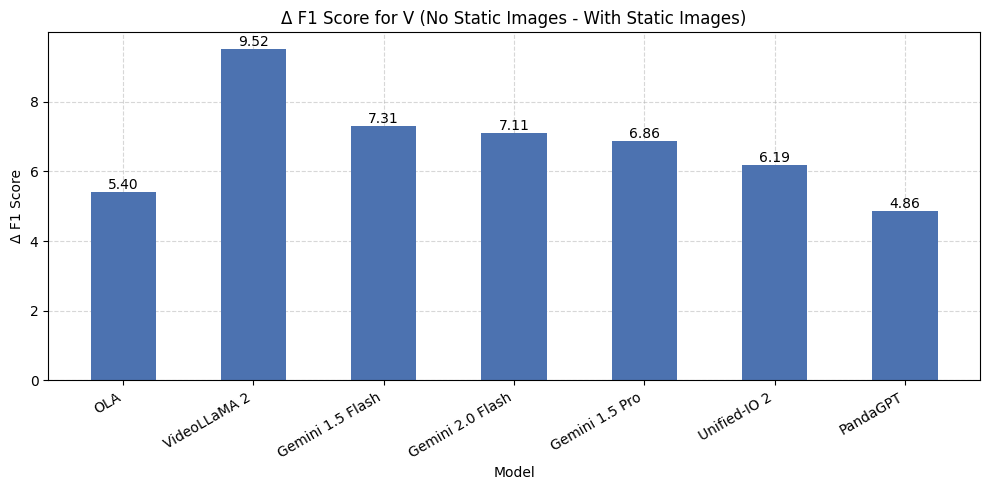

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure the DataFrame is properly formatted
flattened_df = pd.DataFrame(diff_static_image_table.values, index=diff_static_image_table.index, columns=["av"])

x = np.arange(len(flattened_df.index))
width = 0.5  # Make bars wider for cl

const = 1.2
fig, ax = plt.subplots(figsize=(12/const, 6/const))

# Draw grid first, then bars so grid is behind
ax.grid(True, which='both', linestyle='--', alpha=0.5, zorder=0)
bars = ax.bar(x, flattened_df["av"], width, color="#4C72B0", label="Δ F1 (no BGM - BGM)", zorder=2)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 0),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(flattened_df.index, rotation=30, ha='right')
ax.set_title('Δ F1 Score for V (No Static Images - With Static Images)')
ax.set_xlabel('Model')
ax.set_ylabel('Δ F1 Score')
# ax.legend(title='Difference')

plt.tight_layout()
plt.savefig("diff_static_image.png", dpi=300, bbox_inches='tight')
plt.show()

## Voice over

In [ ]:

from vggsounder.benchmark import benchmark
from vggsounder.labels import VGGSounder

models_path = "../../supplimentary/models-results"
csv_path= "../../supplimentary/data/vggsounder+background-music.csv"
display_names = {
    "ola": "OLA",
    "video-llama-2-av": "VideoLLaMA 2",
    "gemini-1.5-flash": "Gemini 1.5 Flash",
    "gemini-2.0-flash": "Gemini 2.0 Flash",
    "gemini-1.5-pro": "Gemini 1.5 Pro",
    "unified-io-2": "Unified-IO 2",
    "pandagpt": "PandaGPT",
}

# no voice over
vggsounder = VGGSounder(csv_path=csv_path)
vggsounder.set_meta_filters(voice_over=False)
no_voice_over_ids = [video.video_id for video in vggsounder]


no_voice_over_table = benchmark(
    models_path=models_path,
    display_names=display_names,
    metrics=[
        ("f1",["a"]),
    ],
    subset_ids=no_voice_over_ids,
    dataset_path=csv_path
)
no_voice_over_table

# voice over
vggsounder.set_meta_filters(voice_over=True)
voice_over_ids = [video.video_id for video in vggsounder]


voice_over_table = benchmark(
    models_path=models_path,
    display_names=display_names,
    metrics=[
        ("f1",["a"]),
    ],
    subset_ids=voice_over_ids,
    dataset_path=csv_path
)
voice_over_table


diff_voice_over_table =  no_voice_over_table - voice_over_table
diff_voice_over_table


  0%|          | 0/7 [00:00<?, ?it/s]

/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['wind rustiling leaves'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['wind rustiling leaves'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(
/Users/ewriji/Desktop/work/vggsounder/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['female speech, woman someone'] will be ignored
  warnings.warn(


  0%|          | 0/7 [00:00<?, ?it/s]

metric,f1
modality,a
OLA,-10.091284
VideoLLaMA 2,3.969227
Gemini 1.5 Flash,-17.251452
Gemini 2.0 Flash,-0.195220
Gemini 1.5 Pro,-18.163835
Unified-IO 2,4.981597
PandaGPT,-3.916475


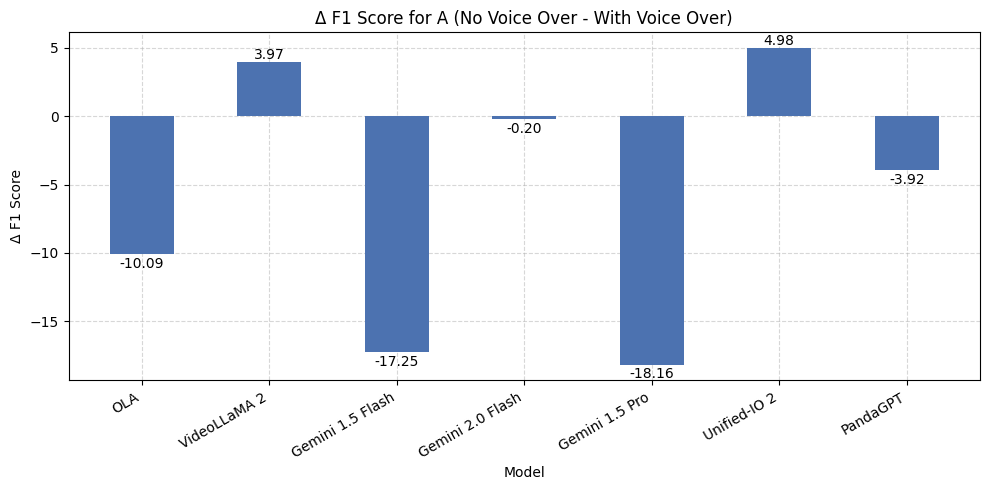

In [5]:


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure the DataFrame is properly formatted
flattened_df = pd.DataFrame(diff_voice_over_table.values, index=diff_voice_over_table.index, columns=["av"])

x = np.arange(len(flattened_df.index))
width = 0.5  # Make bars wider for clarity

const = 1.2
fig, ax = plt.subplots(figsize=(12 / const, 6 / const))

# Draw grid first, then bars so grid is behind
ax.grid(True, which='both', linestyle='--', alpha=0.5, zorder=0)
bars = ax.bar(x, flattened_df["av"], width, color="#4C72B0", label="Δ F1 (no BGM - BGM)", zorder=2)


# Add a horizontal line at y=0 so that axis is visible
# ax.axhline(0, color='black', linewidth=1, linestyle='--')

# Add value labels outside the bars (above for positive, below for negative)
for bar in bars:
    height = bar.get_height()
    if height >= 0:
        # Place label above the bar
        ax.annotate(f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 0),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
    else:
        # Place label below the bar (outside)
        ax.annotate(f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, -2),  # 10 points vertical offset downward
                    textcoords="offset points",
                    ha='center', va='top', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(flattened_df.index, rotation=30, ha='right')
ax.set_title('Δ F1 Score for A (No Voice Over - With Voice Over)')
ax.set_xlabel('Model')
ax.set_ylabel('Δ F1 Score')

plt.tight_layout()
plt.savefig("diff_voice_over.png", dpi=300, bbox_inches='tight')
plt.show()

# Modality confusion

In [2]:
from vggsounder.benchmark import analyze_modality_confusion_detailed
from vggsounder import VGGSounder

# Analyze modality confusion for a specific model
confusion_analysis = analyze_modality_confusion_detailed(
    models_path="../../supplimentary/models-results",
    model_name="gemini-1.5-flash",  # Model name without .pkl extension
    vggsounder=VGGSounder(background_music=None, voice_over=None, static_image=None)
)

print(f"Found {len(confusion_analysis)} samples with modality confusion")

# Filter by specific confusion types
audio_confused = confusion_analysis[confusion_analysis['confused_a'] == True]
visual_confused = confusion_analysis[confusion_analysis['confused_v'] == True]
combined_confused = confusion_analysis[confusion_analysis['confused_av'] == True]

print(f"Audio confusion: {len(audio_confused)} samples")
print(f"Visual confusion: {len(visual_confused)} samples")
print(f"Combined confusion: {len(combined_confused)} samples")

# Examine specific confused samples
display_cols = ['id', 'ground_truth', 'pred_a', 'pred_v', 'pred_av', 'confused_a', 'confused_v', 'confused_av']
print("\nFirst 3 audio-confused samples:")
print(audio_confused[display_cols].head(3))

# Example: Find samples that are audio-confused but not visual-confused
audio_only_confused = confusion_analysis[
    (confusion_analysis['confused_a'] == True) & 
    (confusion_analysis['confused_v'] == False)
]
print(f"Audio-only confusion: {len(audio_only_confused)} samples")

Found 2625 samples with modality confusion
Audio confusion: 2228 samples
Visual confusion: 612 samples
Combined confusion: 215 samples

First 3 audio-confused samples:
                   id                                       ground_truth  \
0  -0jeONf82dE_000021        [horse neighing, male speech, man speaking]   
1  -3Kv4fdm7Uk_000030  [plastic bottle crushing, playing flute, playi...   
2  -3RH8_aeZkk_000105                        [male speech, man speaking]   

                                       pred_a              pred_v  \
0                 [male speech, man speaking]                  []   
1  [male speech, man speaking, playing flute]  [playing steelpan]   
2                 [male speech, man speaking]                  []   

              pred_av  confused_a  confused_v  confused_av  
0   [horse clip-clop]        True       False        False  
1  [playing steelpan]        True       False        False  
2                  []        True       False        False  
Audio-